## <center> Assignment 4. Sarcasm detection with logistic regression
    
We'll be using the dataset from the [paper](https://arxiv.org/abs/1704.05579) "A Large Self-Annotated Corpus for Sarcasm" with >1mln comments from Reddit, labeled as either sarcastic or not. A processed version can be found on Kaggle in a form of a [Kaggle Dataset](https://www.kaggle.com/danofer/sarcasm).

Sarcasm detection is easy. 

<img src="https://habrastorage.org/webt/1f/0d/ta/1f0dtavsd14ncf17gbsy1cvoga4.jpeg" />

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [11]:
pd.set_option("max_colwidth",200) # ontrola cuántos caracteres se muestran en las columnas de texto cuando printeo

In [12]:
df = pd.read_csv("C:/Users/titea/Downloads/Datasets_NLP/train-balanced-sarcasm.csv")
df

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd prefer is she lived in NC as well."
1,0,You do know west teams play against west teams more than east teams right?,Shbshb906,nba,-4,-1,-1,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 seed) did not even carry a good enough record to make the playoffs in the east last year.
2,0,"They were underdogs earlier today, but since Gronk's announcement this afternoon, the Vegas line has moved to patriots -1",Creepeth,nfl,3,3,0,2016-09,2016-09-22 21:45:37,They're favored to win.
3,0,"This meme isn't funny none of the ""new york nigga"" ones are.",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,2016-10-18 21:03:47,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,2016-12-30 17:00:13,Yep can confirm I saw the tool they use for that. It was made by our boy EASports_MUT
...,...,...,...,...,...,...,...,...,...,...
1010821,1,I'm sure that Iran and N. Korea have the technology to create a pig/bird/human hybrid virus.,TwarkMain,reddit.com,2,2,0,2009-04,2009-04-25 00:47:52,"No one is calling this an engineered pathogen, but there are reports that this virus has bits of human, pig and bird genetic material, which makes it uniquely interesting"
1010822,1,"whatever you do, don't vote green!",BCHarvey,climate,1,1,0,2009-05,2009-05-14 22:27:40,"In a move typical of their recent do-nothing approach to CO2 emissions, Canada appoints a tar sands executive to liaise with the US on climate change"
1010823,1,Perhaps this is an atheist conspiracy to make Christians look bad?,rebelcommander,atheism,1,1,0,2009-01,2009-01-11 00:22:57,Screw the Disabled--I've got to get to Church on Time
1010824,1,The Slavs got their own country - it is called Kosovo,catsi,worldnews,1,1,0,2009-01,2009-01-23 21:12:49,"I've always been unsettled by that. I hear a lot of Jewish people say that Israel can do whatever it pleases because of the holocaust, but the Slavs, and other races the Germans attempted to annih..."


In [13]:
# target es el label, que indica si el comentario es sarcástico o no
# 0 normal
# 1 coment sarcástico

# Detección de sarcasmo
Para este ejercicio vas a utilizar el dataset del paper [A Large Self-Annotated Corpus for Sarcasm](https://arxiv.org/abs/1704.05579), con un millón de comentarios de Reddit, etiquetados como sarcásticos o no sarcásticos. Se pide:
1. Si hubiese missings, eliminalos


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010826 entries, 0 to 1010825
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   label           1010826 non-null  int64 
 1   comment         1010771 non-null  object
 2   author          1010826 non-null  object
 3   subreddit       1010826 non-null  object
 4   score           1010826 non-null  int64 
 5   ups             1010826 non-null  int64 
 6   downs           1010826 non-null  int64 
 7   date            1010826 non-null  object
 8   created_utc     1010826 non-null  object
 9   parent_comment  1010826 non-null  object
dtypes: int64(4), object(6)
memory usage: 77.1+ MB


In [15]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1010771 entries, 0 to 1010825
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   label           1010771 non-null  int64 
 1   comment         1010771 non-null  object
 2   author          1010771 non-null  object
 3   subreddit       1010771 non-null  object
 4   score           1010771 non-null  int64 
 5   ups             1010771 non-null  int64 
 6   downs           1010771 non-null  int64 
 7   date            1010771 non-null  object
 8   created_utc     1010771 non-null  object
 9   parent_comment  1010771 non-null  object
dtypes: int64(4), object(6)
memory usage: 84.8+ MB


2. Comprueba que está balanceado

In [16]:
df['label'].value_counts(normalize=True)
# el df está balanceado y eso es bueno
# evita que el modelo favorezca una clase por defecto

label
0    0.500017
1    0.499983
Name: proportion, dtype: float64

In [17]:
df[df['label']==1]
# filtroy muestro las filas donde label es 1 (coment sarcásticos)

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
33,1,But they'll have all those reviews!,RoguishPoppet,ProductTesting,0,-1,-1,2016-11,2016-11-01 02:04:59,"The dumb thing is, they are risking their seller account, too."
44,1,"wow it is totally unreasonable to assume that the agency that covered up Bush war crimes because ""muh republican party"" would be partisan as fuck",pb2crazy,politics,2,-1,-1,2016-11,2016-11-01 02:42:11,Clinton campaign accuses FBI of 'blatant double standard'
45,1,Ho ho ho... But Melania said that there is no way it could have happened because she didn't know the woman!,pb2crazy,politics,8,-1,-1,2016-10,2016-10-18 16:20:53,Anyone else think that it was interesting the way she mentioned that she had a tape recorder in her hand while he was assaulting her...
66,1,I can't wait until @potus starts a twitter war against Morning Joe.,kitduncan,politics,3,-1,-1,2016-11,2016-11-01 03:22:33,Here's what happens when Obama gives up his Twitter account
69,1,gotta love the teachers who give exams on the day after halloween,DEP61,CFBOffTopic,3,-1,-1,2016-11,2016-11-01 03:30:11,Monday night Drinking thread Brought to You by Infuriating capitalization Inconsistencies
...,...,...,...,...,...,...,...,...,...,...
1010821,1,I'm sure that Iran and N. Korea have the technology to create a pig/bird/human hybrid virus.,TwarkMain,reddit.com,2,2,0,2009-04,2009-04-25 00:47:52,"No one is calling this an engineered pathogen, but there are reports that this virus has bits of human, pig and bird genetic material, which makes it uniquely interesting"
1010822,1,"whatever you do, don't vote green!",BCHarvey,climate,1,1,0,2009-05,2009-05-14 22:27:40,"In a move typical of their recent do-nothing approach to CO2 emissions, Canada appoints a tar sands executive to liaise with the US on climate change"
1010823,1,Perhaps this is an atheist conspiracy to make Christians look bad?,rebelcommander,atheism,1,1,0,2009-01,2009-01-11 00:22:57,Screw the Disabled--I've got to get to Church on Time
1010824,1,The Slavs got their own country - it is called Kosovo,catsi,worldnews,1,1,0,2009-01,2009-01-23 21:12:49,"I've always been unsettled by that. I hear a lot of Jewish people say that Israel can do whatever it pleases because of the holocaust, but the Slavs, and other races the Germans attempted to annih..."


In [18]:
# voy a limpiar el df antes me meterme con el train y test

In [19]:
df['comment'] = df['comment'].str.replace('[^\w\s]', "")
# quitosignos de puntuación

df['comment'] = df['comment'].str.lower()

df[df['label']==1]

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
33,1,but they'll have all those reviews!,RoguishPoppet,ProductTesting,0,-1,-1,2016-11,2016-11-01 02:04:59,"The dumb thing is, they are risking their seller account, too."
44,1,"wow it is totally unreasonable to assume that the agency that covered up bush war crimes because ""muh republican party"" would be partisan as fuck",pb2crazy,politics,2,-1,-1,2016-11,2016-11-01 02:42:11,Clinton campaign accuses FBI of 'blatant double standard'
45,1,ho ho ho... but melania said that there is no way it could have happened because she didn't know the woman!,pb2crazy,politics,8,-1,-1,2016-10,2016-10-18 16:20:53,Anyone else think that it was interesting the way she mentioned that she had a tape recorder in her hand while he was assaulting her...
66,1,i can't wait until @potus starts a twitter war against morning joe.,kitduncan,politics,3,-1,-1,2016-11,2016-11-01 03:22:33,Here's what happens when Obama gives up his Twitter account
69,1,gotta love the teachers who give exams on the day after halloween,DEP61,CFBOffTopic,3,-1,-1,2016-11,2016-11-01 03:30:11,Monday night Drinking thread Brought to You by Infuriating capitalization Inconsistencies
...,...,...,...,...,...,...,...,...,...,...
1010821,1,i'm sure that iran and n. korea have the technology to create a pig/bird/human hybrid virus.,TwarkMain,reddit.com,2,2,0,2009-04,2009-04-25 00:47:52,"No one is calling this an engineered pathogen, but there are reports that this virus has bits of human, pig and bird genetic material, which makes it uniquely interesting"
1010822,1,"whatever you do, don't vote green!",BCHarvey,climate,1,1,0,2009-05,2009-05-14 22:27:40,"In a move typical of their recent do-nothing approach to CO2 emissions, Canada appoints a tar sands executive to liaise with the US on climate change"
1010823,1,perhaps this is an atheist conspiracy to make christians look bad?,rebelcommander,atheism,1,1,0,2009-01,2009-01-11 00:22:57,Screw the Disabled--I've got to get to Church on Time
1010824,1,the slavs got their own country - it is called kosovo,catsi,worldnews,1,1,0,2009-01,2009-01-23 21:12:49,"I've always been unsettled by that. I hear a lot of Jewish people say that Israel can do whatever it pleases because of the holocaust, but the Slavs, and other races the Germans attempted to annih..."


3. Divide el dataset en train test. Qué forma tienen?

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    df['comment'],
    df['label'],
    test_size=0.2, # 20% test 80% train, as always
    random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(808616,)
(202155,)
(808616,)
(202155,)


## Tasks:
1. Analyze the dataset, make some plots. This [Kernel](https://www.kaggle.com/sudalairajkumar/simple-exploration-notebook-qiqc) might serve as an example


In [26]:
str(df[df['label']==0]['comment'])
# filtro coment NO sarcásticos
# convierto cada coment en único str gigante
# WordCloud trabaja con un str

'0                                                                                                                                                         nc and nh.\n1                                                                                         you do know west teams play against west teams more than east teams right?\n2                                          they were underdogs earlier today, but since gronk\'s announcement this afternoon, the vegas line has moved to patriots -1\n3                                                                                                       this meme isn\'t funny none of the "new york nigga" ones are.\n4                                                                                                                                    i could use one of those tools.\n                                                                                     ...                                                                            \n1

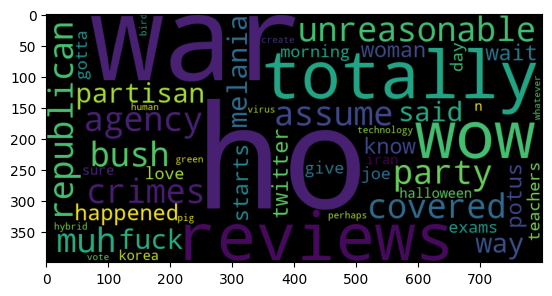

In [ ]:
from wordcloud import WordCloud, STOPWORDS
# wordcloud genera la imagen de nube de palabras
# stopwords par apalabras que no aportan info

wordcloud = WordCloud(
    stopwords=STOPWORDS,
    max_words=50, # 50 palabras más frecuentes
    random_state=42,
    width=800,
    height=400)

wordcloud.generate(str(df[df['label']==1]['comment']))
# genero coment sarcásticos
# las palabras más grandes son las que aparecen más veces en los comentarios sarcásticos

plt.imshow(wordcloud);

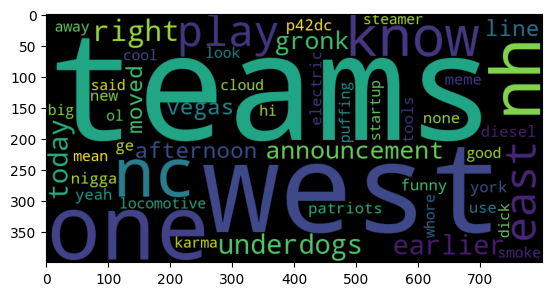

In [ ]:
# lo mismo con los coment 
wordcloud = WordCloud(
    stopwords=STOPWORDS,
    max_words=50,
    random_state=42,
    width=800,
    height=400)

wordcloud.generate(str(df[df['label']==0]['comment']))
# genero los no sarcásticos
# comparar esta nube con la anterior permite ver si hay vocabulario diferente entre clases

plt.imshow(wordcloud)

In [ ]:
# nube de no sarcástico (0)
# teams, one, west, know, right, play - deportes??
# today, afternoon, announcement - cotidiano??
# quizás e sun tono más neutro

# nube de sarcástico (1)
# war, totally, reviews, wow, unreasonable, covered, republican, partisan,
# bush, crimes, potus, iran, korea, totally, wow, unreasonable
# vocab mucho más político y emocional

# comentarios sarcásticos en reddit tienden a venir de debates políticos
# hipérbole y exageración mientras que los no sarcásticos son lo contrario

# para el modelo igual es fácil aprender a distinguirlos xq vocab de cada clase es bastante diferente

2. Build a Tf-Idf + logistic regression pipeline to predict sarcasm (`label`) based on the text of a comment on Reddit (`comment`).

In [ ]:
import plotly.graph_objs as go
from plotly import tools
import plotly.offline as py

In [ ]:
from collections import defaultdict
# defaultdict es como un diccionario normal pero con un valor por defecto para claves nuevas
# defaultdict(int) → devuelve 0 automáticamente si la clave no existe
# muy útil para contar: no hace falta comprobar si la clave ya existe antes de sumar 1

train1_df = df[df["label"]==1]  # subconjunto solo con comentarios SARCÁSTICOS (label=1)
train0_df = df[df["label"]==0]  # subconjunto solo con comentarios NO SARCÁSTICOS (label=0)


## Función que genera n-gramas a partir de un texto ##
def generate_ngrams(text, n_gram=1):
    token = [
        token                                  # guardamos la palabra si cumple ambas condiciones
        for token in text.lower().split(" ")   # dividimos el texto por espacios y pasamos a minúsculas
        if token != ""                         # ignoramos strings vacíos (espacios dobles generan "")
        if token not in STOPWORDS              # ignoramos palabras vacías ('the', 'is', 'a'...)
    ]
    ngrams = zip(*[token[i:] for i in range(n_gram)])
    # zip(*[...]) combina listas desplazadas para crear tuplas de n palabras consecutivas
    # ejemplo con n_gram=2 y tokens=['I','love','this','film']:
    #   zip(['I','love','this','film'], ['love','this','film'])
    #   → ('I','love'), ('love','this'), ('this','film')
    return [" ".join(ngram) for ngram in ngrams]
    # convierte cada tupla en un string: ('not', 'good') → 'not good'


## Función que crea un gráfico de barras horizontales con Plotly ##
def horizontal_bar_chart(df, color):
    trace = go.Bar(
        y=df["word"].values[::-1],       # palabras en el eje Y
                                          # [::-1] invierte el orden para que la más frecuente quede arriba
        x=df["wordcount"].values[::-1],  # frecuencias en el eje X (también invertidas)
        showlegend=False,                 # no mostramos leyenda (no es necesaria aquí)
        orientation='h',                  # 'h' = barras horizontales (en vez de verticales)
        marker=dict(color=color),         # color de las barras
    )
    return trace  # devolvemos el objeto gráfico para añadirlo al subplot después


## Contar UNIGRAMAS en comentarios NO SARCÁSTICOS ##
freq_dict = defaultdict(int)              # contador vacío: claves nuevas empiezan en 0
for sent in train0_df["comment"]:         # iteramos por cada comentario no sarcástico
    for word in generate_ngrams(sent):    # generamos todos los unigramas de ese comentario
        freq_dict[word] += 1              # sumamos 1 al contador de esa palabra

fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
# freq_dict.items() → lista de tuplas (palabra, frecuencia)
# sorted(..., key=lambda x: x[1]) → ordena por el segundo elemento de cada tupla (la frecuencia)
# [::-1] → invierte: de mayor a menor frecuencia
# pd.DataFrame(...) → convierte la lista de tuplas en un DataFrame de dos columnas

fd_sorted.columns = ["word", "wordcount"]  # renombramos las columnas con nombres descriptivos
trace0 = horizontal_bar_chart(fd_sorted.head(50), 'blue')  # gráfico con las 50 palabras más frecuentes


## Contar UNIGRAMAS en comentarios SARCÁSTICOS (proceso idéntico) ##
freq_dict = defaultdict(int)
for sent in train1_df["comment"]:
    for word in generate_ngrams(sent):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace1 = horizontal_bar_chart(fd_sorted.head(50), 'blue')


## Montamos la figura con dos subplots lado a lado ##
fig = tools.make_subplots(
    rows=1, cols=2,             # 1 fila y 2 columnas → dos gráficos uno al lado del otro
    vertical_spacing=0.04,      # espacio vertical entre subplots
    subplot_titles=[            # títulos que aparecen encima de cada subplot
        "Frequent words of not sarcastic comments",
        "Frequent words of sarcastic comments"
    ]
)
fig.append_trace(trace0, 1, 1)  # añade el gráfico no-sarcástico: fila 1, columna 1
fig.append_trace(trace1, 1, 2)  # añade el gráfico sarcástico: fila 1, columna 2
fig['layout'].update(
    height=1200,
    width=900,
    paper_bgcolor='rgb(233,233,233)',  # color gris claro de fondo del lienzo
    title="Word Count Plots"
)
py.iplot(fig, filename='word-plots')  # renderiza el gráfico interactivo dentro del notebook

In [ ]:
## BIGRAMAS (n_gram=2): pares de palabras consecutivas ##
# Los bigramas capturan expresiones como 'not good' o 'so great'
# que tienen un significado conjunto distinto al de cada palabra por separado

freq_dict = defaultdict(int)
for sent in train0_df["comment"]:
    for word in generate_ngrams(sent, 2):  # n_gram=2 → genera pares de palabras consecutivas
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace0 = horizontal_bar_chart(fd_sorted.head(50), 'blue')

freq_dict = defaultdict(int)
for sent in train1_df["comment"]:
    for word in generate_ngrams(sent, 2):  # mismo proceso para los comentarios sarcásticos
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace1 = horizontal_bar_chart(fd_sorted.head(50), 'blue')

fig = tools.make_subplots(rows=1, cols=2, vertical_spacing=0.04,
                          subplot_titles=["Frequent words of not sarcastic comments",
                                          "Frequent words of sarcastic comments"])
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig['layout'].update(height=1200, width=900, paper_bgcolor='rgb(233,233,233)', title="Word Count Plots")
py.iplot(fig, filename='word-plots')

In [ ]:
## TRIGRAMAS (n_gram=3): tríos de palabras consecutivas ##
# Más contexto que los bigramas, pero también más específicos y menos frecuentes
# Pueden capturar expresiones sarcásticas de tres palabras como 'yeah right sure'

freq_dict = defaultdict(int)
for sent in train0_df["comment"]:
    for word in generate_ngrams(sent, 3):  # n_gram=3 → tríos de palabras consecutivas
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace0 = horizontal_bar_chart(fd_sorted.head(50), 'blue')

freq_dict = defaultdict(int)
for sent in train1_df["comment"]:
    for word in generate_ngrams(sent, 3):  # trigramas para los comentarios sarcásticos
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace1 = horizontal_bar_chart(fd_sorted.head(50), 'blue')

fig = tools.make_subplots(rows=1, cols=2, vertical_spacing=0.04,
                          subplot_titles=["Frequent words of not sarcastic comments",
                                          "Frequent words of sarcastic comments"])
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig['layout'].update(height=1200, width=900, paper_bgcolor='rgb(233,233,233)', title="Word Count Plots")
py.iplot(fig, filename='word-plots')

3. Plot the words/bigrams which a most predictive of sarcasm 